In [22]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns 
import statsmodels.formula.api as smf
import plotly.express as px


In [2]:
walmart = pd.read_csv("STORE_STATUS_PUBLIC_VIEW_3007829193429392206.csv")

walmart.head()

,OBJECTID,businessUnit_name,businessUnit_number,Description,Type,Address,City,County,State,Postal Code,Operation Status,GlobalID,x,y
0,51077,"ROGERS, AR",1,WM Supercenter,Retail,2110 W WALNUT ST,ROGERS,BENTON,AR,72756-3246,Open,29e01211-412e-47e1-85e9-a4162a9680ca,-1.048062e+07,4.346304e+06
1,51078,HARRISON AR,2,WM Supercenter,Retail,161 N WALMART DR,HARRISON,BOONE,AR,72601-1960,Open,2e5c7c63-3469-4572-9713-e43b3554c329,-1.036820e+07,4.337694e+06
2,51079,COMMERCE GA,3,WM Supercenter,Retail,30983 HIGHWAY 441 S,COMMERCE,JACKSON,GA,30529-6655,Open,42a1faa5-f7aa-4b66-bd07-694501e68678,-9.290317e+06,4.062122e+06
3,51080,SILOAM SPRINGS AR,4,WM Supercenter,Retail,2901 HIGHWAY 412 E,SILOAM SPRINGS,BENTON,AR,72761-8673,Open,5ae6449c-7a76-4bb8-a574-fa89ad1c9dc5,-1.052109e+07,4.325893e+06
4,51081,CONWAY AR,5,WM Supercenter,Retail,1155 HWY 65 NORTH,CONWAY,FAULKNER,AR,72032-2857,Open,b195cb36-dc6c-481e-9149-5f07f3aa1d86,-1.029004e+07,4.178649e+06


lets try to clean it up a bit ??

In [5]:
walmart.shape

(5209, 14)

In [12]:
walmart.isna()

,OBJECTID,businessUnit_name,businessUnit_number,Description,Type,Address,City,County,State,Postal Code,Operation Status,GlobalID,x,y
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5204,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5205,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5206,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5207,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
walmart.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5204    False
5205    False
5206    False
5207    False
5208    False
Length: 5209, dtype: bool

In [10]:
walmart.value_counts()

OBJECTID  businessUnit_name   businessUnit_number  Description                 Type       Address                City            County     State  Postal Code  Operation Status  GlobalID                              x              y           
51077     ROGERS, AR          1                    WM Supercenter              Retail     2110 W WALNUT ST       ROGERS          BENTON     AR     72756-3246   Open              29e01211-412e-47e1-85e9-a4162a9680ca  -1.048062e+07  4.346304e+06    1
51078     HARRISON AR         2                    WM Supercenter              Retail     161 N WALMART DR       HARRISON        BOONE      AR     72601-1960   Open              2e5c7c63-3469-4572-9713-e43b3554c329  -1.036820e+07  4.337694e+06    1
51079     COMMERCE GA         3                    WM Supercenter              Retail     30983 HIGHWAY 441 S    COMMERCE        JACKSON    GA     30529-6655   Open              42a1faa5-f7aa-4b66-bd07-694501e68678  -9.290317e+06  4.062122e+06    1
51080    

In [17]:
print(walmart["State"].value_counts().head(50))

State
TX    590
FL    386
CA    303
NC    214
GA    210
IL    177
OH    170
PA    159
MO    156
TN    150
VA    148
AL    143
LA    138
OK    134
AR    129
IN    126
AZ    124
SC    122
MI    117
NY    111
CO    104
KY    101
WI     97
MS     86
KS     82
MN     79
NJ     70
IA     69
WA     64
UT     59
MD     57
NM     53
NV     50
MA     48
NE     47
WV     44
OR     43
CT     32
NH     28
ID     27
PR     26
ME     25
SD     17
ND     17
MT     16
WY     14
HI     11
DE     10
RI      9
AK      9
Name: count, dtype: int64


thats the number of stores or "walmart" by the state 

In [19]:
## lets take a look at what we have here

walmart.head()

## i guess we can filter out the unuseful columns

useful_columns = [
    "businessUnit_name",
    "businessUnit_number",
    "Description",
    "Type",
    "Address",
    "City",
    "County",
    "State",
    "Postal Code",
    "Operation Status",
    "x",
    "y"
]



In [20]:
walmart_clean = walmart[useful_columns]

In [ ]:
walmart_clean.head()

## looks better ish 

,businessUnit_name,businessUnit_number,Description,Type,Address,City,County,State,Postal Code,Operation Status,x,y
0,"ROGERS, AR",1,WM Supercenter,Retail,2110 W WALNUT ST,ROGERS,BENTON,AR,72756-3246,Open,-1.048062e+07,4.346304e+06
1,HARRISON AR,2,WM Supercenter,Retail,161 N WALMART DR,HARRISON,BOONE,AR,72601-1960,Open,-1.036820e+07,4.337694e+06
2,COMMERCE GA,3,WM Supercenter,Retail,30983 HIGHWAY 441 S,COMMERCE,JACKSON,GA,30529-6655,Open,-9.290317e+06,4.062122e+06
3,SILOAM SPRINGS AR,4,WM Supercenter,Retail,2901 HIGHWAY 412 E,SILOAM SPRINGS,BENTON,AR,72761-8673,Open,-1.052109e+07,4.325893e+06
4,CONWAY AR,5,WM Supercenter,Retail,1155 HWY 65 NORTH,CONWAY,FAULKNER,AR,72032-2857,Open,-1.029004e+07,4.178649e+06


## what are we trying to see lets see i guess poke around and guess how many questions we can answer like how many stores in Texas and the answer is 590 so lets get to poking and answer some questions


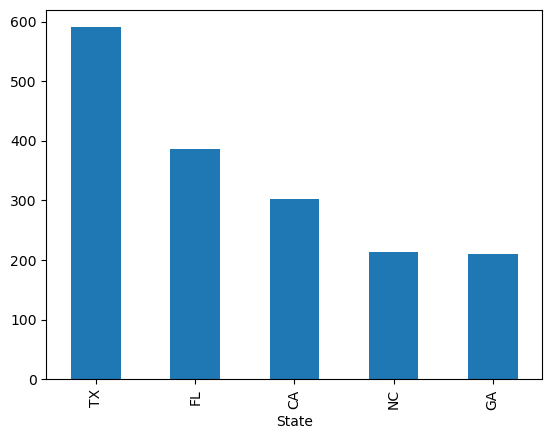

In [23]:
walmart_clean["State"].value_counts().head().plot(kind = "bar"
                                                )
plt.show()

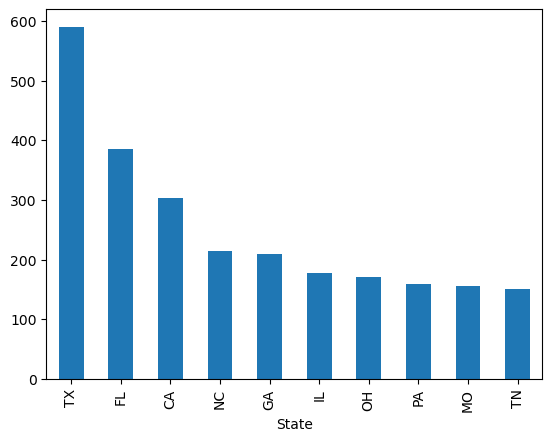

In [24]:
walmart_clean["State"].value_counts().head(10).plot(kind = "bar"
                                                )
plt.show()

# okay so thats the top 10 states in the number of walmarts they have there is also a type column lets make a better chart though

<function matplotlib.pyplot.show(close=None, block=None)>

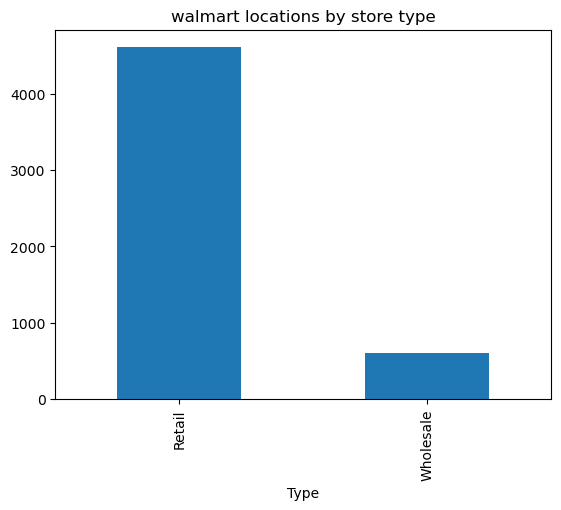

In [27]:
type_counts = walmart_clean["Type"].value_counts()

type_counts.plot(kind= "bar")
plt.title("walmart locations by store type")
plt.show

# okay so there is 2 types retail which is the walmart side of things and sams club would probably be the whole sale side of things thats a big difference  and answer more answers along the way 

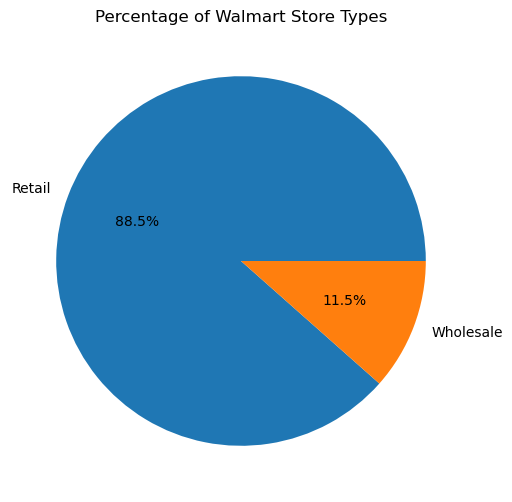

In [28]:
plt.figure(figsize=(6,6))
type_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Percentage of Walmart Store Types")

plt.show()

# okay so 11.5 percent of the walmart companies business is retail maybe we can find data to see how much money they generate? lets see the entirety of walmart location as a scatter plot

In [30]:
fig = px.scatter_geo(
    walmart_clean,
    lat="y",
    lon="x",
    hover_name="businessUnit_name",
    hover_data=["City", "State", "Type", "Description"],
    scope="usa",
    title="Walmart Store Locations in the United States"
)

fig.show()

# why does it look like that -_- 

# lets see what else can i do do i need more data on how much money they can generate? i dont have money data ?
# ill try to find more data idk im thinking what else i can do with this dataset ??


